<a href="https://colab.research.google.com/github/OvidioAscencio/Parcial/blob/main/Parcial4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

EJERCICIO 1
Dataset cargado correctamente: 607 transacciones

TOP 10 REGLAS
                   antecedents              consequents   support  confidence  \
141       (Latte, Leche_extra)         (Combo_desayuno)  0.022222    0.666667   
121      (Sandwich, Capuchino)            (Combo_tarde)  0.022222    0.571429   
140    (Latte, Combo_desayuno)            (Leche_extra)  0.022222    0.444444   
143              (Leche_extra)  (Latte, Combo_desayuno)  0.022222    0.235294   
126        (Croissant, Sirope)              (Capuchino)  0.022222    1.000000   
145        (Ensalada, Galleta)       (Combo_estudiante)  0.022222    1.000000   
125        (Capuchino, Panini)              (Croissant)  0.022222    1.000000   
164              (Dona, Latte)                 (Muffin)  0.033333    1.000000   
134  (Combo_desayuno, Galleta)       (Combo_estudiante)  0.044444    0.888889   
117     (Croissant, Chocolate)              (Capuchino)  0.033333    0.857143   

         lift  
141  5.000000  


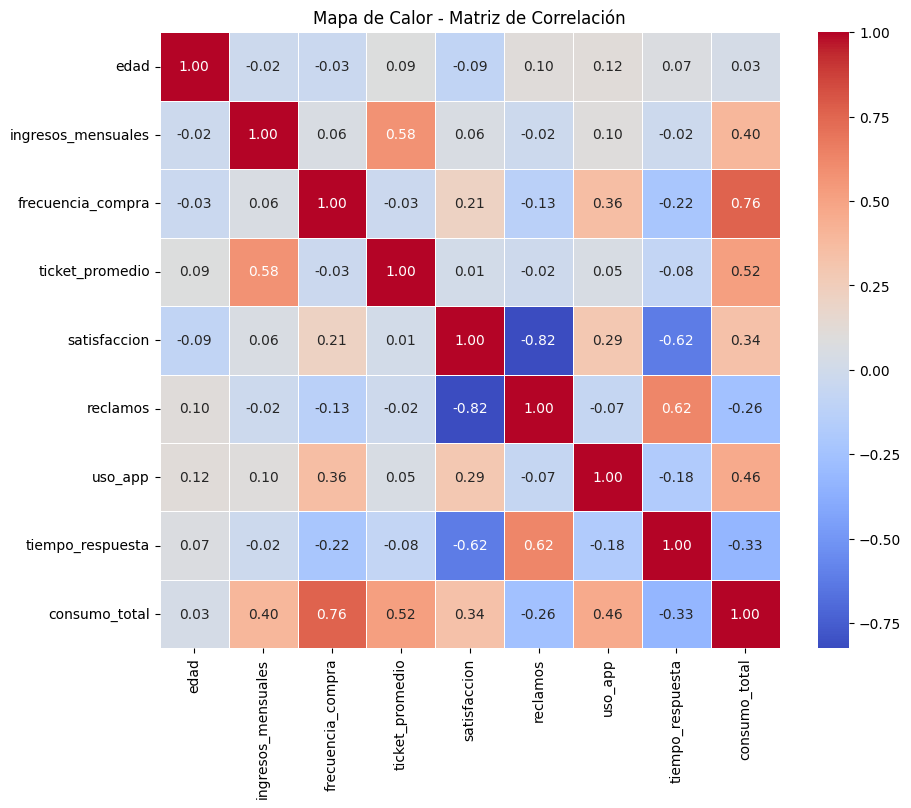



EJERCICIO 3


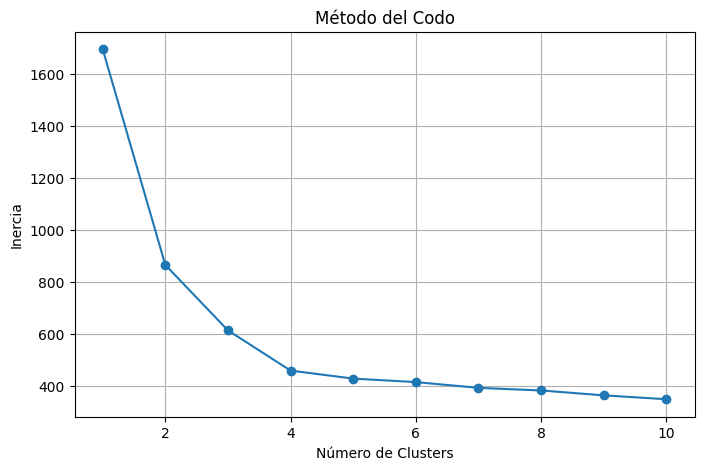


Distribución de clientes por cluster:
Cluster
0    118
1     66
2     58
Name: count, dtype: int64

Promedios por Cluster:
          edad  ingresos  frecuencia_uso  gasto_promedio  satisfaccion  \
Cluster                                                                  
0        32.74    706.81            2.87           43.14          5.48   
1        33.91   1011.48            6.65           81.88          7.97   
2        48.24   1571.45            8.79          146.60          8.83   

         reclamos  antiguedad_meses  
Cluster                              
0            3.83              8.69  
1            1.17             19.00  
2            0.83             36.67  


In [4]:
import warnings
warnings.filterwarnings("ignore")
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

print("EJERCICIO 1")
print("="*60)

url_asociacion = "https://raw.githubusercontent.com/OvidioAscencio/Parcial/refs/heads/main/DataSet/clave_D_asociacion.csv"
asociacion = pd.read_csv(url_asociacion)

print(f"Dataset cargado correctamente: {asociacion.shape[0]:,} transacciones")


transacciones = asociacion.groupby('transaccion_id')['item'].apply(list).tolist()

te = TransactionEncoder()
te_array = te.fit(transacciones).transform(transacciones)
df_transacciones = pd.DataFrame(te_array, columns=te.columns_)

frecuentes = apriori(df_transacciones, min_support=0.02, use_colnames=True)
reglas = association_rules(frecuentes, metric="confidence", min_threshold=0.2)
reglas_ordenadas = reglas.sort_values(by="lift", ascending=False)

print("\nTOP 10 REGLAS")
print(reglas_ordenadas[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10))


print("\n\nEJERCICIO 2")
print("="*60)

url_correlacion = "https://raw.githubusercontent.com/OvidioAscencio/Parcial/refs/heads/main/DataSet/clave_D_correlacion.csv"
correlacion = pd.read_csv(url_correlacion)

variables_numericas = correlacion.select_dtypes(include=['int64', 'float64'])

print(f"Variables numéricas identificadas: {list(variables_numericas.columns)}")


matriz_correlacion = variables_numericas.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(matriz_correlacion, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Mapa de Calor - Matriz de Correlación")
plt.show()



print("\n\nEJERCICIO 3")
print("="*60)

url_cluster = "https://raw.githubusercontent.com/OvidioAscencio/Parcial/refs/heads/main/DataSet/clave_D_agrupacion.csv"
cluster = pd.read_csv(url_cluster)

variables_cluster = cluster.select_dtypes(include=['int64', 'float64']).fillna(0)


escalador = StandardScaler()
datos_escalados = escalador.fit_transform(variables_cluster)


inercias = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(datos_escalados)
    inercias.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), inercias, marker='o')
plt.title("Método del Codo")
plt.xlabel("Número de Clusters")
plt.ylabel("Inercia")
plt.grid(True)
plt.show()


modelo = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster['Cluster'] = modelo.fit_predict(datos_escalados)

print("\nDistribución de clientes por cluster:")
print(cluster['Cluster'].value_counts())

print("\nPromedios por Cluster:")
print(cluster.groupby('Cluster')[variables_cluster.columns].mean().round(2))

